<a href="https://colab.research.google.com/github/PankajKhanwariya/PankajKhanwariya/blob/main/Time_Series_Bitcoin_price_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
!pip install yfinance
import yfinance as yf

In [3]:
df = yf.download("BTC-USD", start="2014-09-15")

# 3. Clean up the dataframe structure
df = df.reset_index()

# Handle multi-level columns if present in newer yfinance versions
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

/tmp/ipykernel_396/2289886715.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2014-09-15")
[*********************100%***********************]  1 of 1 completed


In [4]:
df_cleaned = df[['Date','Close']]
df_cleaned.shape

(4331, 2)

In [5]:
df_cleaned.isnull().sum()

,0
Price,
Date,0
Close,0


In [6]:
df_cleaned = df_cleaned.set_index('Date')

# Smoothening

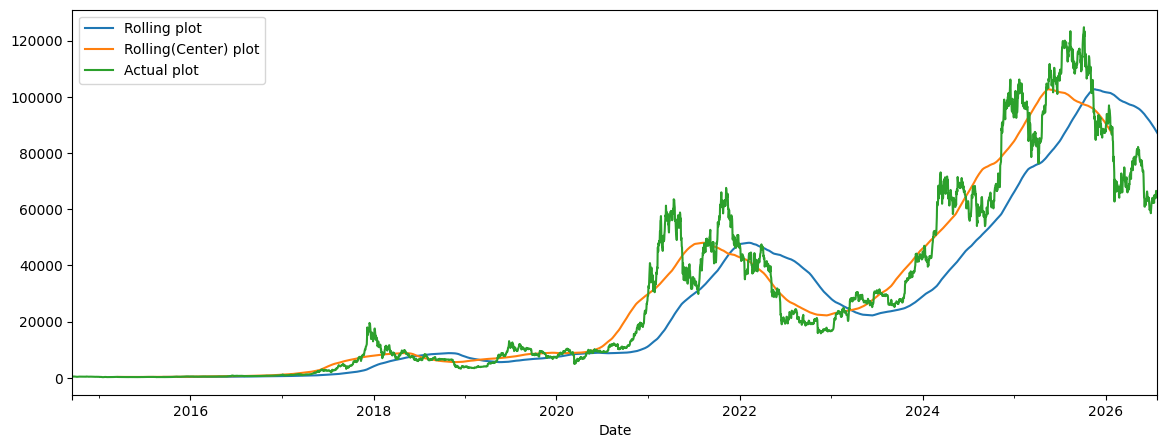

In [7]:
plt.figure(figsize=(14,5))
df_cleaned.Close.rolling(365).mean().plot(label='Rolling plot') # Normal smoothening
df_cleaned.Close.rolling(365, center=True).mean().plot(label='Rolling(Center) plot') # Normal smoothening

df_cleaned.Close.plot(label='Actual plot')
plt.legend()

In [8]:
df_cleaned.columns.name=None

# Anomaly hnadling

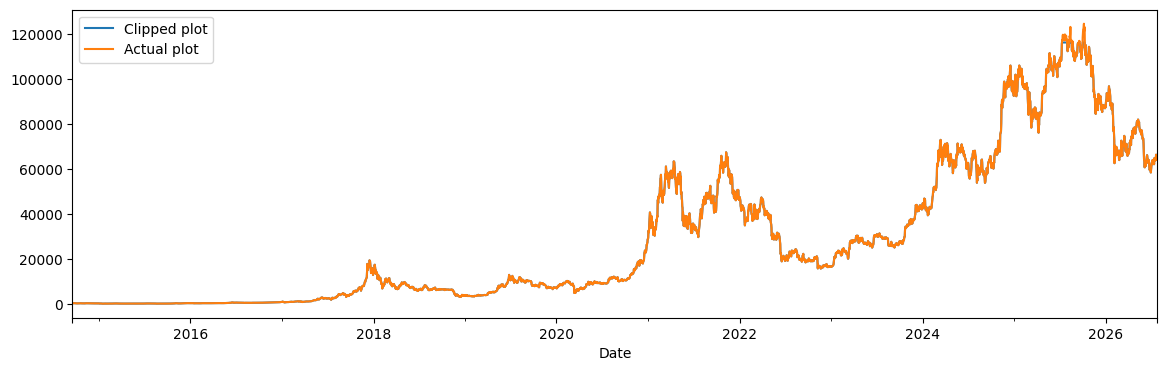

In [9]:
plt.figure(figsize=(14,4))
df_cleaned.Close.clip(lower=df_cleaned.Close.quantile(0.01), upper=df_cleaned.Close.quantile(0.99)).plot(label='Clipped plot')
df_cleaned.Close.plot(label='Actual plot')
plt.legend()

# Decomposing Trend Seasonality Error component

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing

In [11]:
plt.figure(figsize=(14,10))
model = seasonal_decompose(df_cleaned['Close'], model='multiplicative', period=365); #, period=365


<Figure size 1400x1000 with 0 Axes>

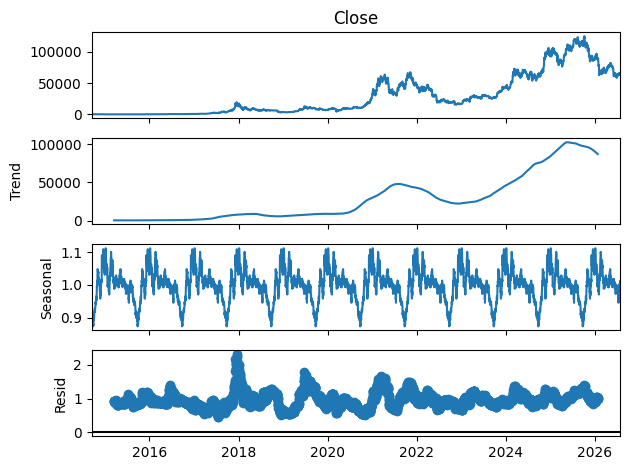

In [12]:
model.plot();
plt.show()

<Axes: xlabel='Date'>

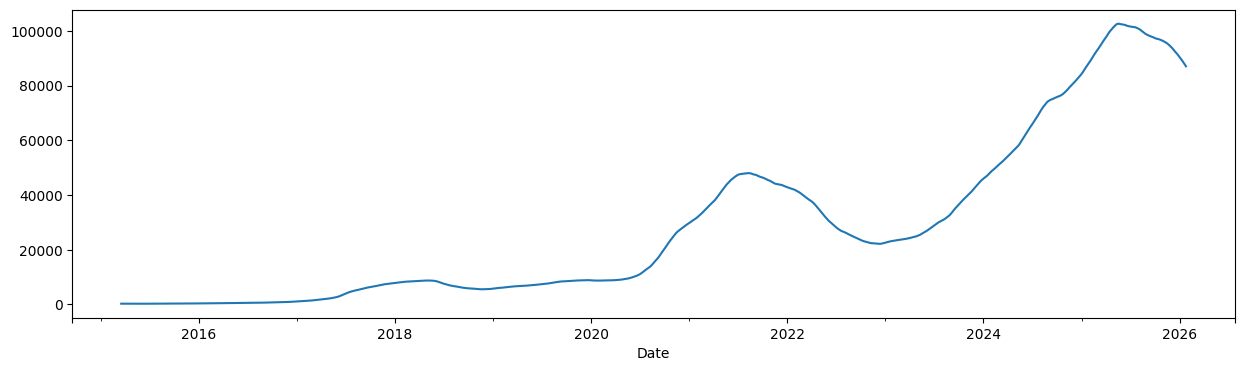

In [13]:
plt.figure(figsize=(15,4))
model.trend.plot()

<Axes: xlabel='Date'>

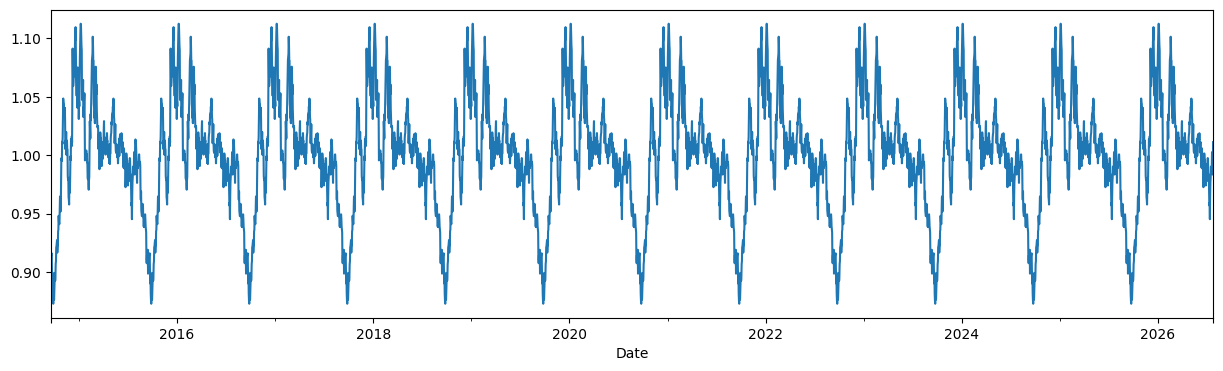

In [14]:
plt.figure(figsize=(15,4))
model.seasonal.plot()

<Axes: xlabel='Date'>

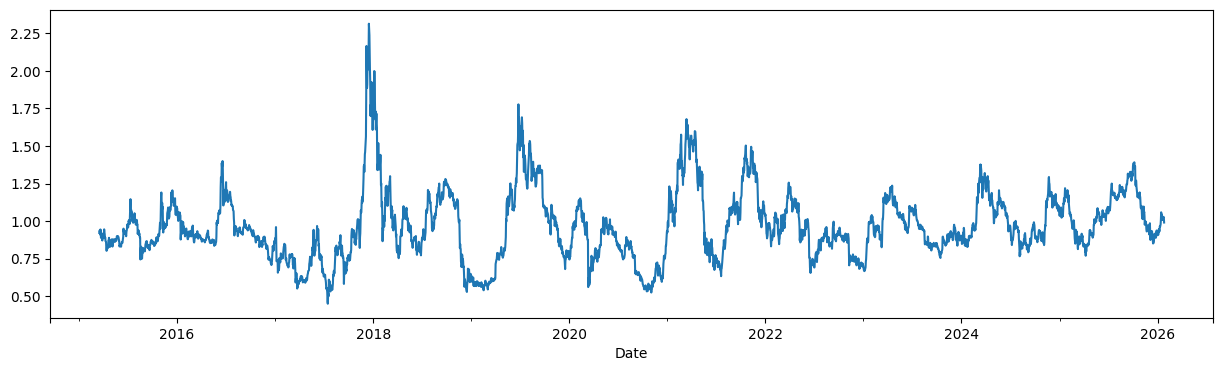

In [15]:
plt.figure(figsize=(15,4))
model.resid.plot()

# Smoothing with moving averages

<Axes: xlabel='Date'>

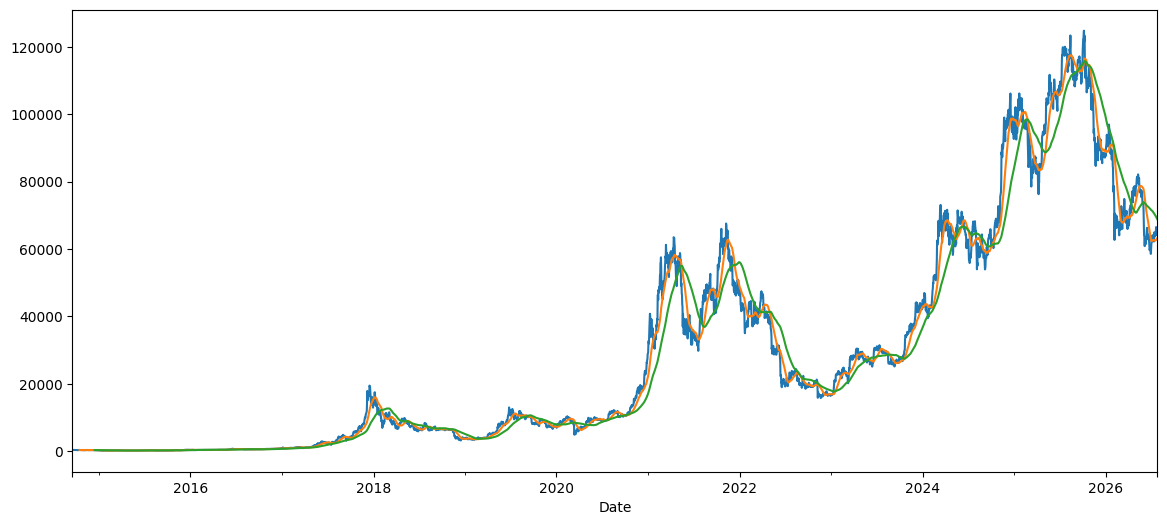

In [16]:
plt.figure(figsize=(14,6))
df_cleaned.Close.plot(label='Actual Plot')
df_cleaned.Close.rolling(30).mean().plot(label='30 Day MA Plot')
df_cleaned.Close.rolling(90).mean().plot(label='90 Day MA Plot')

# Basic Forecasting

In [17]:
train_set = df_cleaned[df_cleaned.index < df_cleaned.index[-365]]
test_set = df_cleaned[df_cleaned.index >= df_cleaned.index[-365]]

In [18]:
print(train_set.index.max())
print(test_set.index.min())
print(train_set.shape)
print(test_set.shape)

2025-07-26 00:00:00
2025-07-27 00:00:00
(3966, 1)
(365, 1)


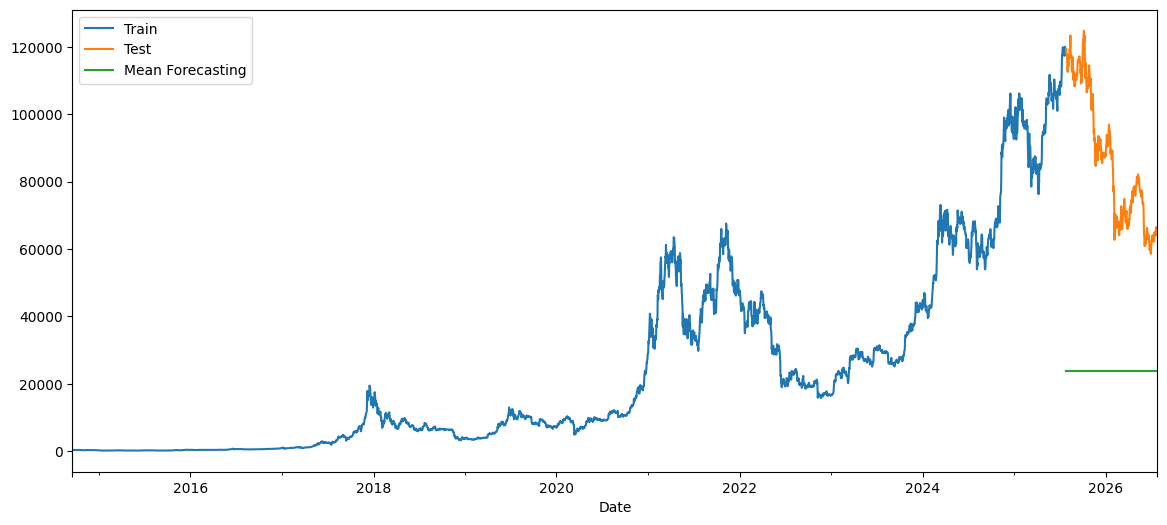

In [19]:
# Mean forecasting
plt.figure(figsize=(14,6))

y_hat = test_set.copy()
y_hat['pred'] = train_set.Close.mean()

train_set.Close.plot(label='Train')
test_set.Close.plot(label='Test')
y_hat.pred.plot(label='Mean Forecasting')
plt.legend()

In [20]:
train_set.Close.mean()

np.float64(23700.72091550149)

/tmp/ipykernel_396/2174621717.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_hat['pred'] = train_set['Close'][-1]


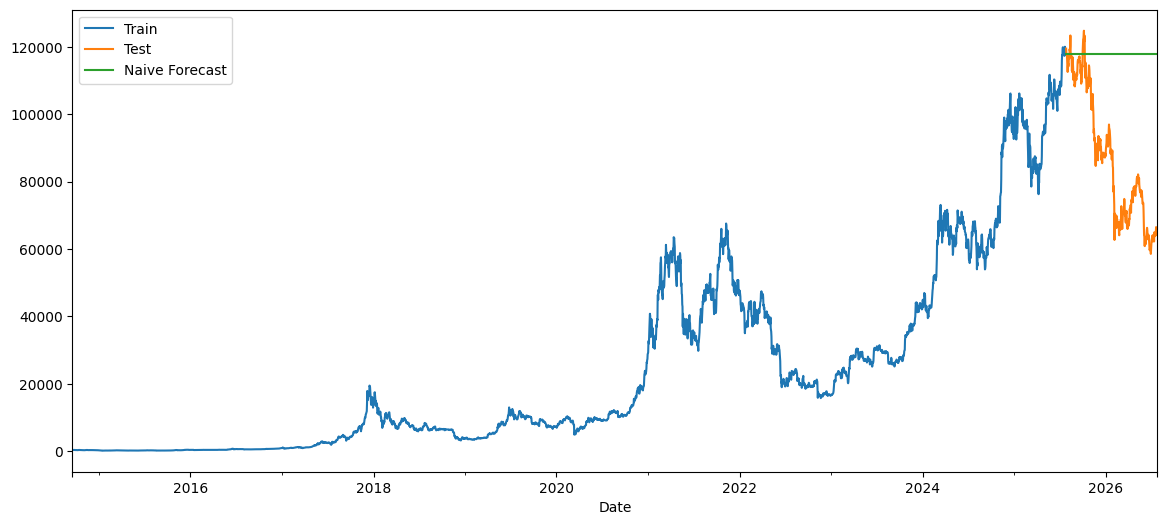

In [21]:
# Naive Method
plt.figure(figsize=(14,6))

y_hat = test_set.copy()

y_hat['pred'] = train_set['Close'][-1]

train_set.Close.plot(label='Train')
test_set.Close.plot(label='Test')
y_hat.pred.plot(label='Naive Forecast')
plt.legend()

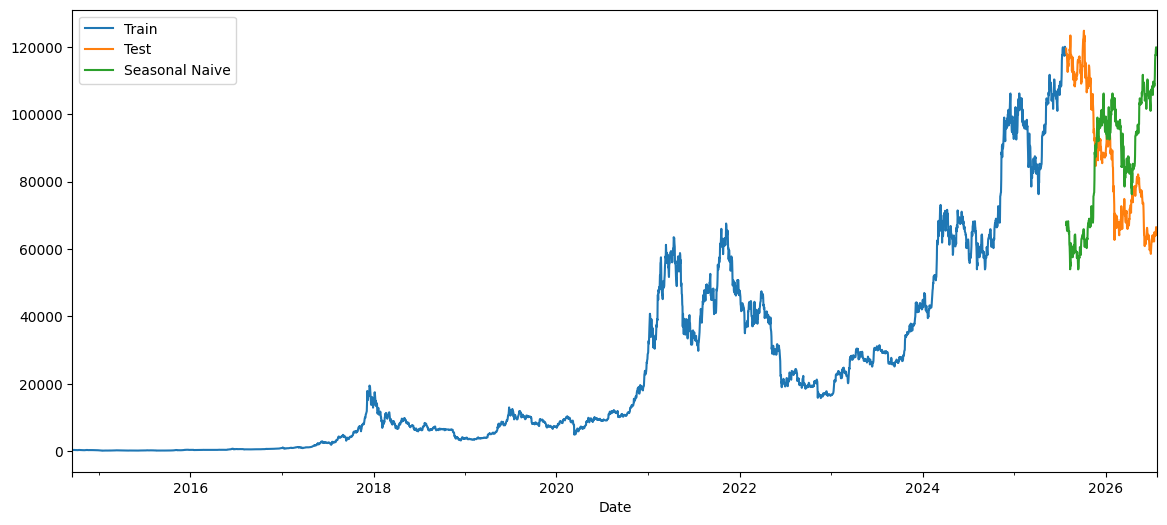

In [22]:
# Seasonal Naive
plt.figure(figsize=(14,6))

y_hat = test_set.copy()
y_hat['price'] = train_set['Close'][-(len(test_set)+7):-7].values

train_set.Close.plot(label='Train')
test_set.Close.plot(label='Test')
y_hat.price.plot(label='Seasonal Naive')
plt.legend()

# Drift Methods

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

def performance(original, prediction):
  print(f'mse : {mean_squared_error(original, prediction)}')
  print(f'rmse : {mean_squared_error(original, prediction)**0.5}')
  print(f'mape : {mean_absolute_percentage_error(original, prediction)}')

In [24]:
# Drift Method:
# Month 1: $10, Month 4: $25 & T = 4 months
# Slope = (25 - 10)/(4 - 1) = $5 per month
# y_hat= 25 + (1 * 5) = $30

In [25]:
drift  = (train_set['Close'][-1] - train_set['Close'][0]) / (len(train_set) -1)
drift

/tmp/ipykernel_396/4112132641.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  drift  = (train_set['Close'][-1] - train_set['Close'][0]) / (len(train_set) -1)


np.float64(29.63178642436505)

In [26]:
y_hat = test_set.copy()

forecast=[]
for i in range(1,len(test_set)+1):
  forecast.append(train_set['Close'][-1] + (i*drift)) # i is acting like a unit-unit increase in x axis to draw line
y_hat['pred'] = forecast

/tmp/ipykernel_396/3972182924.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  forecast.append(train_set['Close'][-1] + (i*drift)) # i is acting like a unit-unit increase in x axis to draw line


In [27]:
test_set['Close']

,Close
Date,
2025-07-27,119448.492188
2025-07-28,117924.476562
2025-07-29,117922.148438
2025-07-30,117831.187500
2025-07-31,115758.203125
...,...
2026-07-22,66100.796875
2026-07-23,65044.812500
2026-07-24,64098.496094


In [28]:
y_hat['pred']

,pred
Date,
2025-07-27,117976.998974
2025-07-28,118006.630760
2025-07-29,118036.262547
2025-07-30,118065.894333
2025-07-31,118095.526120
...,...
2026-07-22,128644.442087
2026-07-23,128674.073873
2026-07-24,128703.705660


In [29]:
performance(test_set['Close'], y_hat['pred'])

mse : 1815657649.5023327
rmse : 42610.53448975186
mape : 0.49617514749390024


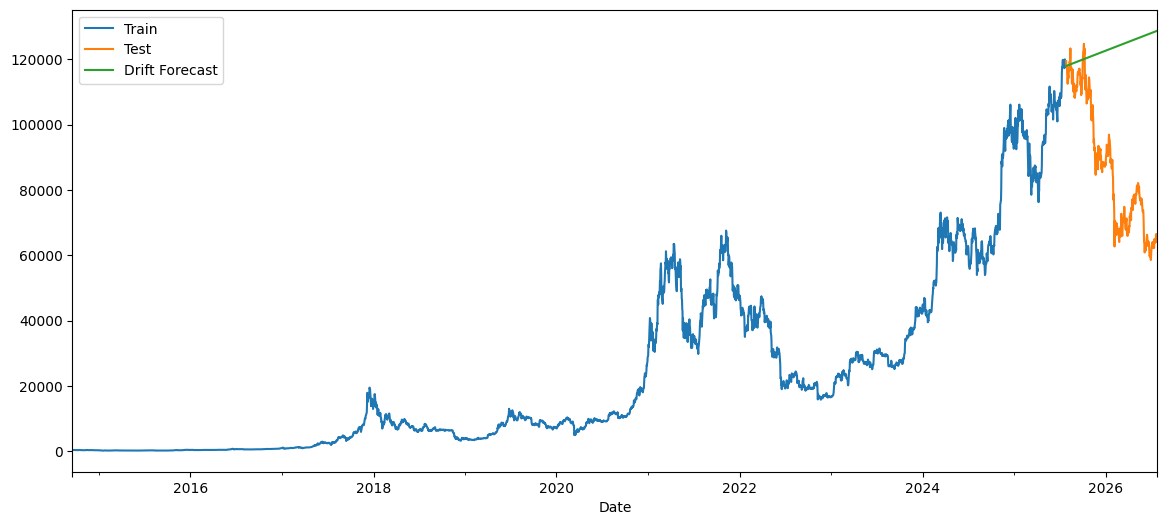

In [30]:
plt.figure(figsize=(14,6))

train_set.Close.plot(label='Train')
test_set.Close.plot(label='Test')
y_hat.pred.plot(label='Drift Forecast')
plt.legend()

# Simple Exponential Smoothing

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

def performance(actual, prediction):
  print(f'mse : {mean_squared_error(actual, prediction)}')
  print(f'mae : {mean_absolute_error(actual, prediction)}')
  print(f'mape :{mean_absolute_percentage_error(actual, prediction)}')

In [32]:
# Simple Exponential Smoothing (No trend and No seasonality)
from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt

In [33]:
# `SimpleExpSmoothing` is the model class.
# `initialization_method='estimated'` tells the model to figure out the best starting point.
ses_model = SimpleExpSmoothing(train_set['Close'], initialization_method='estimated').fit()

# Generate the forecast for the same period as the test data.
y_hat_ses = ses_model.forecast(365)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


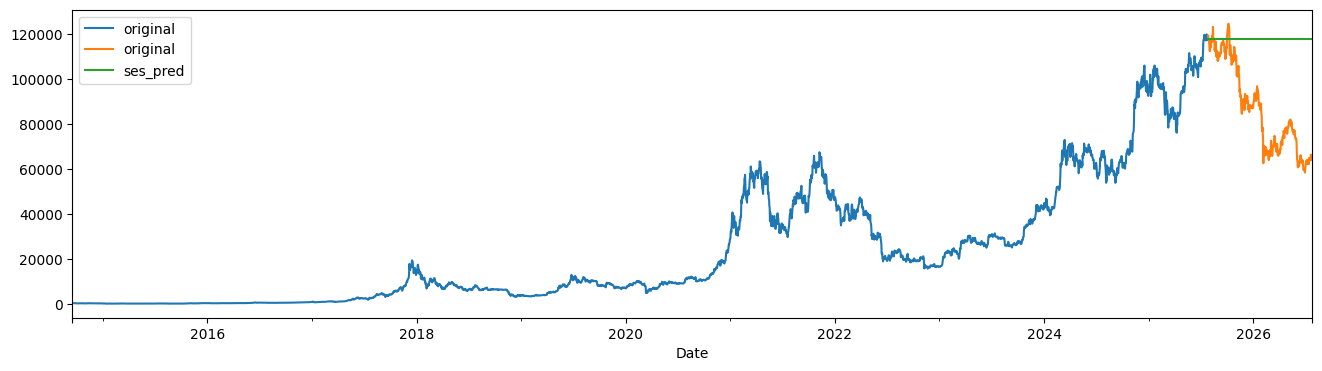

In [34]:
plt.figure(figsize=(16,4))
train_set.Close.plot(label='original')
test_set.Close.plot(label='original')
y_hat_ses.plot(label='ses_pred') #pred.plot(label='ses_pred')
plt.legend()

In [35]:
performance(test_set['Close'], y_hat_ses)

mse : 1329356727.1587505
mae : 31106.071211753526
mape :0.4240785122798687


## Double Exponential Smoothening (Holt's linear trend method)

In [36]:
# Create and fit Holt's model.
# We set `initialization_method='estimated'` again.
holt_model = Holt(train_set['Close'], initialization_method='estimated').fit()

# Generate the forecast.
y_hat_holt = holt_model.forecast(365)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


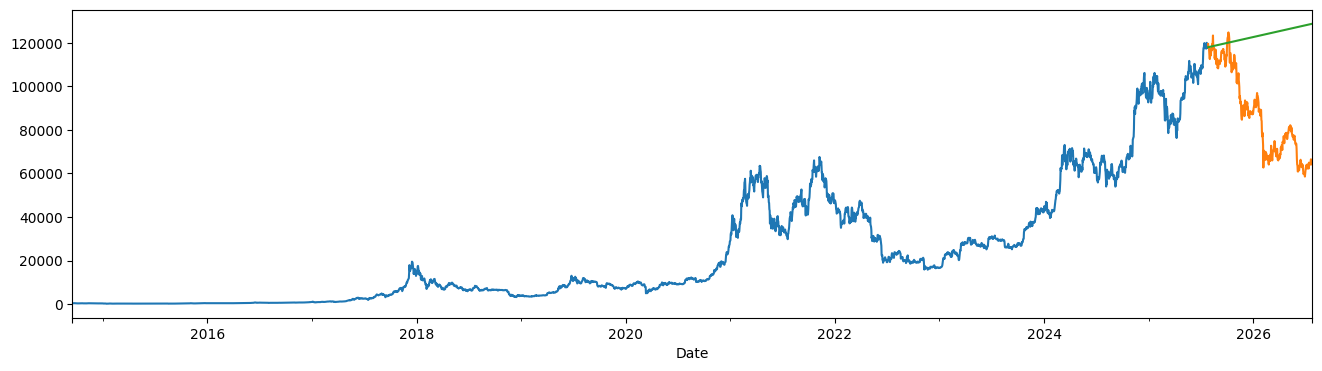

In [37]:
plt.figure(figsize=(16,4))
train_set.Close.plot(label='train')
test_set.Close.plot(label='test')
y_hat_holt.plot(label='pred')
plt.show()

In [38]:
performance(test_set['Close'], y_hat_holt)

mse : 1814655519.9789374
mae : 36419.3344975924
mape :0.4960181193954084


## Tripple exponential method (Holt winter's seasonal method)

In [39]:
hw_model = ExponentialSmoothing(train_set['Close'], trend='add', seasonal='mul', seasonal_periods=365, initialization_method='estimated').fit()

# Generate the forecast.
y_hat_hw = hw_model.forecast(365)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


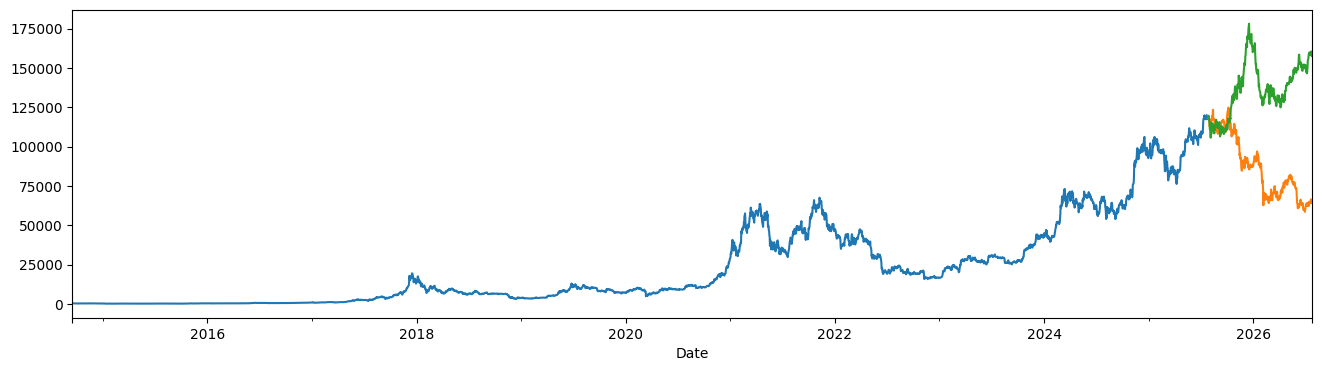

In [40]:
plt.figure(figsize=(16,4))
train_set.Close.plot(label='train')
test_set.Close.plot(label='test')
y_hat_hw.plot(label='pred')
plt.show()

In [41]:
performance(test_set['Close'], y_hat_hw)

mse : 3514462898.030533
mae : 51172.6691259183
mape :0.6845791748536745


# ARIMA & SARIMA forecasting

# Part 2: Advanced Forecasting Techniques

✅ Smoothing Methods (SES, Holt, Holt-Winters)

✅ The Concept of Stationarity and the ADF Test

✅ Making a series stationary with Differencing

✅ Uncovering patterns with ACF and PACF plots

✅ Correlation vs. Causation: A quick but important note

✅ Building our masterpiece: AR, MA, ARMA, and ARIMA models

In [42]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## Step 1: differencing

In [43]:
train_set['diff'] = train_set['Close'].diff().dropna()

/tmp/ipykernel_396/761666810.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set['diff'] = train_set['Close'].diff().dropna()


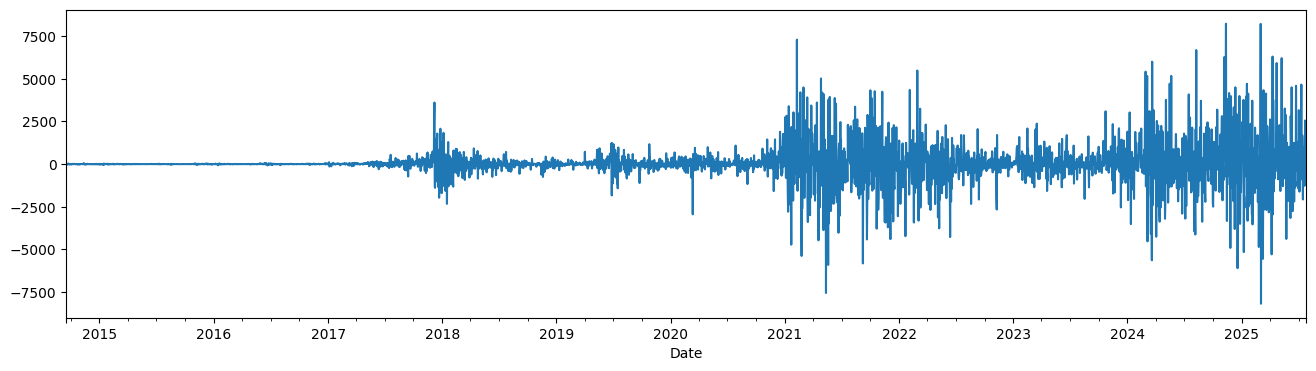

In [44]:
# plot differencing
plt.figure(figsize=(16,4))
train_set['diff'].plot(label='first order differencing')
plt.show()

In [45]:
# augmented dickey fuller test on time series before differencing
adfuller(train_set['Close']) # result[0]: adf statistics, result[1]: P value

(np.float64(0.5268339650868685),
 np.float64(0.9856662721973363),
 31,
 3934,
 {'1%': np.float64(-3.432013338087558),
  '5%': np.float64(-2.8622749717451534),
  '10%': np.float64(-2.5671612338666803)},
 np.float64(65828.69513449498))

In [46]:
# augmented dickey fuller test on time series after differencing
adfuller(train_set['diff'].dropna()) # result[0]: adf statistics, result[1]: P value

(np.float64(-9.268845027401737),
 np.float64(1.343839454617582e-15),
 30,
 3934,
 {'1%': np.float64(-3.432013338087558),
  '5%': np.float64(-2.8622749717451534),
  '10%': np.float64(-2.5671612338666803)},
 np.float64(65811.25780588429))

## step 2: PACF and ACF test

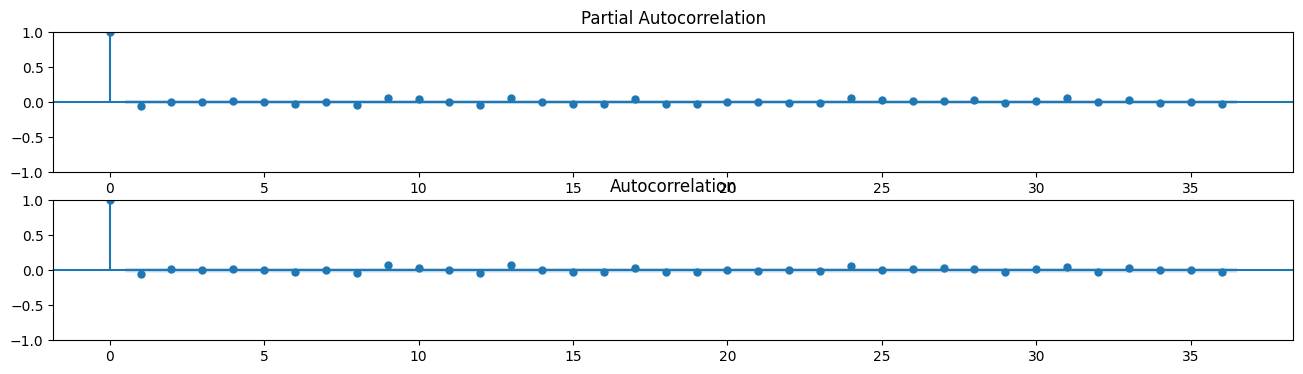

In [47]:
# plotting PACF to find AR
fig, ax = plt.subplots(2,1, figsize=(16,4))

plot_pacf(train_set['diff'].dropna(), ax=ax[0])
plot_acf(train_set['diff'].dropna(), ax=ax[1])

plt.show()

1. When looking at PACF:

       Stops after lag p → AR(p)

       Keeps decreasing gradually (tails off) → Not a pure AR

2. When looking at ACF:

       Stops after lag q → MA(q)

       Keeps decreasing gradually (tails off) → Not a pure MA

In [48]:
# forecasting
model = ARIMA(train_set['Close'], order=(0,1,0))
model_fit = model.fit()

forecast_arima = model_fit.forecast(steps=365)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


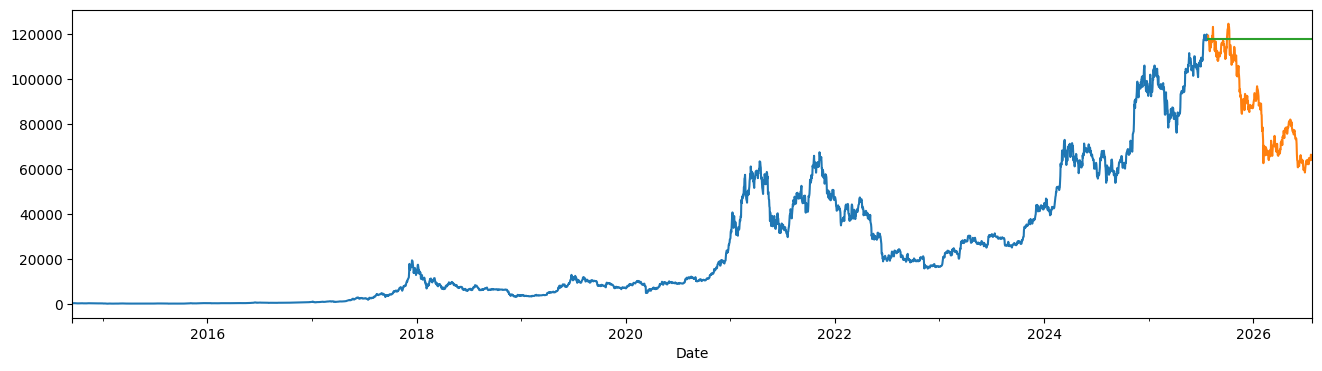

In [49]:
plt.figure(figsize=(16,4))
train_set['Close'].plot(label='train')
test_set['Close'].plot(label='test')
forecast_arima.plot(label='predicted_test')
plt.show()


In [50]:
performance(test_set['Close'], forecast_arima)

mse : 1330240406.9624615
mae : 31119.218878424657
mape :0.42424150833724344


## SARIMA model implementatioon

In [51]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train_set['Close'],
    order=(2,1,1),
    seasonal_order=(1,1,1,12)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [52]:
model_fit_sarima = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [54]:
forecast_sarima = model_fit_sarima.forecast(steps=365)

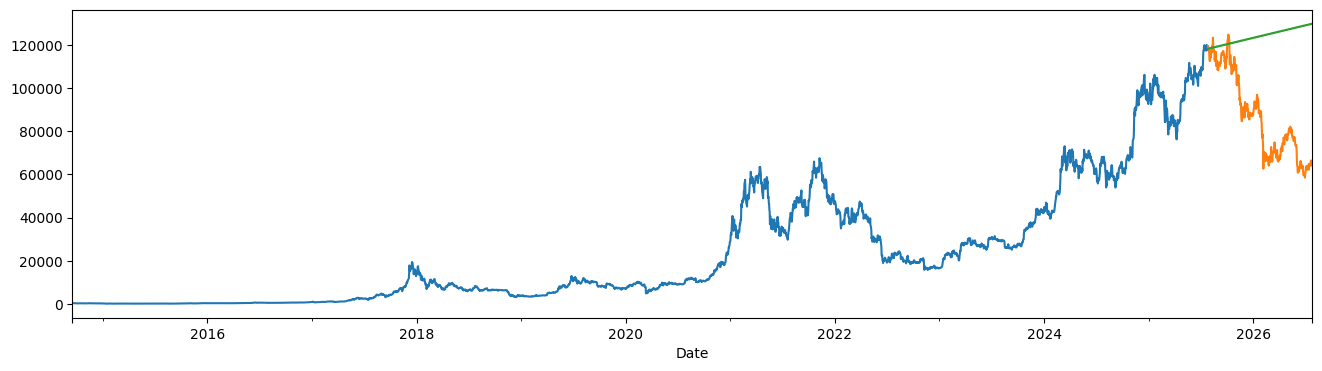

In [57]:
plt.figure(figsize=(16,4))
train_set.Close.plot(label='train')
test_set.Close.plot(label='test')
forecast_sarima.plot(label='forecasting')

plt.show()

In [58]:
performance(test_set['Close'], forecast_sarima)

mse : 1873870212.0639534
mae : 37062.44817489475
mape :0.5044486536110137
